---
date: "2026-07-28"
date-modified: last-modified
format:
  html:
    toc: true
---


# ARMA Models

## 1\. Autoregressive Moving Average Model: ARMA(p,q)

In some applications, the [AR](autoregressive-models.ipynb) or [MA](moving-average-models.ipynb) models alone would require a very large number of parameters (a high order $p$ or $q$) to adequately describe the dynamic structure of the data. To keep the model parsimonious (fewer parameters), we combine them into an Autoregressive Moving Average model.

::: {#def-arma-pq}
## ARMA(p,q) Model
A time series $\{r_t\}$ follows an ARMA(p,q) model if it satisfies:
$$
r_t = \phi_0 + \sum_{i=1}^p \phi_i r_{t-i} + a_t - \sum_{i=1}^q \theta_i a_{t-i}
$$
where $\{a_t\}$ is a white noise series. The hyperparameters are $p$ (the autoregressive order) and $q$ (the moving average order).
:::

## 2\. Stationarity of ARMA Models

Since the moving average component (the $q$ part) is always weakly stationary (as it's a finite linear combination of white noise), the stationarity of an ARMA(p,q) process depends entirely on the autoregressive (AR) component.

::: {#thm-arma-stationarity}
## Stationarity of ARMA(p,q)
We rewrite the ARMA(p,q) model using the [backward shift operator](autoregressive-models.ipynb) $B$:
$$
(1 - \phi_1 B - \dots - \phi_p B^p) r_t = \phi_0 + (1 - \theta_1 B - \dots - \theta_q B^q) a_t
$$
For the model to be weakly stationary, we must check the roots of the autoregressive characteristic equation:
$$
1 - \phi_1 x - \dots - \phi_p x^p = 0
$$
If all roots (denoted $\omega_i$) satisfy $|\omega_i| > 1$ (they lie outside the unit circle), the ARMA(p,q) model is weakly stationary.
:::

## 3\. Model Selection: Choosing p and q

Because the theoretical [ACF](autocorrelation-and-stationarity.ipynb) and [PACF](autoregressive-models.ipynb) for mixed ARMA models do not have simple cut-offs (both decay over time), we rely heavily on Information Criteria to select the hyperparameters $p$ and $q$.

We fit models across a grid of possible $(p,q)$ pairs and select the one that minimizes:
- **AIC (Akaike Information Criterion):** Tends to select slightly larger models.
- **BIC (Bayesian Information Criterion):** Applies a heavier penalty for the number of parameters and tends to select simpler models.

## 4\. Limitations of ARMA Models: Linear Correlation vs Dependence

An important limitation of AR, MA, and ARMA models is that they only capture **linear correlation** (measured by ACF and PACF). However, two variables can be completely uncorrelated but still highly dependent.

::: {.callout-warning}
## Uncorrelated does NOT mean Independent
Autocorrelation only captures linear relationships. If the relationship is non-linear, the correlation might be zero even if one variable completely determines the other.
:::

::: {.callout-note}
## Intuition: $X$ and $X^2$
Suppose $X \sim N(0,1)$ and $Y = X^2$. 
$Y$ is entirely dependent on $X$. However, their covariance is:
$$
\text{Cov}(X, Y) = E[XY] - E[X]E[Y] = E[X^3] - 0 \cdot E[X^2]
$$
Because the standard normal distribution is symmetric, its third moment $E[X^3] = 0$. Therefore, $\text{Cov}(X, Y) = 0$ and the correlation is zero, despite $X$ and $Y$ having deterministic dependence.
:::

Because of this limitation, if a time series has zero autocorrelation, we cannot definitively say it is independent. We must test for non-linear dependence (for example, by checking the autocorrelation of squared returns $r_t^2$). 



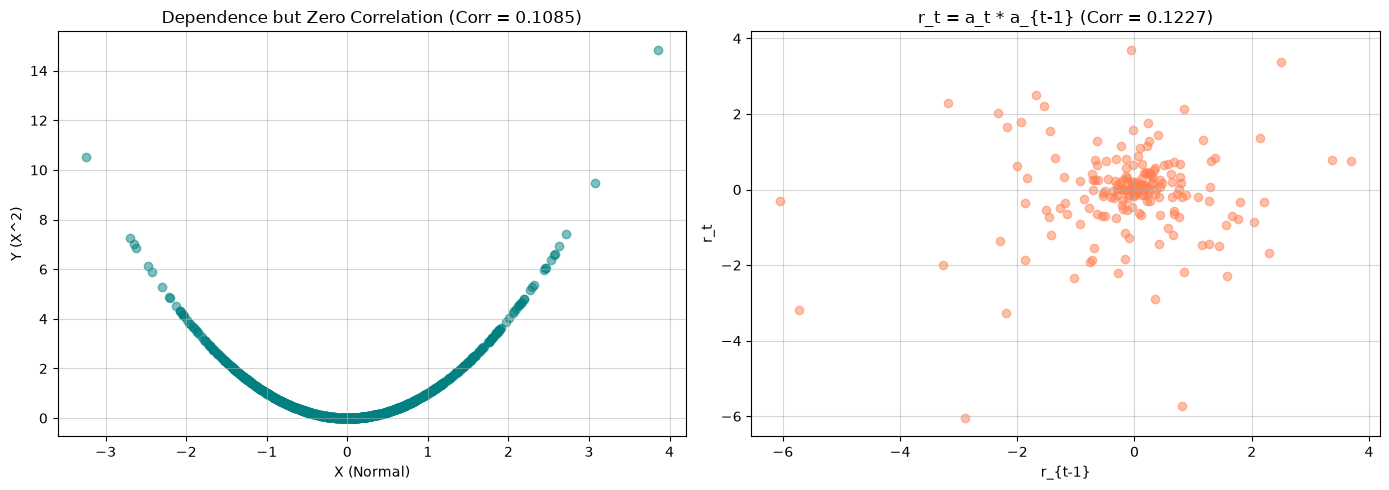

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate X ~ N(0,1)
X = np.random.normal(0, 1, 1000)
# Generate Y = X^2
Y = X**2

# Calculate correlation
correlation = np.corrcoef(X, Y)[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot the scatter plot
axes[0].scatter(X, Y, alpha=0.5, color='teal')
axes[0].set_title(f"Dependence but Zero Correlation (Corr = {correlation:.4f})")
axes[0].set_xlabel("X (Normal)")
axes[0].set_ylabel("Y (X^2)")
axes[0].grid(True, alpha=0.5)

# Simulate zero correlation time series with dependence
# a_t is white noise, r_t = a_t * a_{t-1}
# They have zero linear correlation, but strong dependence
a_t = np.random.normal(0, 1, 201)
r_t = a_t[1:] * a_t[:-1]
r_t_minus_1 = r_t[:-1]
r_t_curr = r_t[1:]

corr_rt = np.corrcoef(r_t_curr, r_t_minus_1)[0, 1]

axes[1].scatter(r_t_minus_1, r_t_curr, alpha=0.5, color='coral')
axes[1].set_title(f"r_t = a_t * a_{{t-1}} (Corr = {corr_rt:.4f})")
axes[1].set_xlabel("r_{t-1}")
axes[1].set_ylabel("r_t")
axes[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()


> **References & Acknowledgments:**
> Notes adapted from *Analysis of Financial Time Series*, 2nd/3rd Edition by Ruey S. Tsay.
